In [12]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score


In [3]:
#load auto mpg dataset
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

#display first five rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
#seperate input and output
X=df[['displacement']]
y=df['mpg']
#check missing values
print(f"Missing values in X{X.isnull().sum()}")
print(f"Missing values in y{y.isnull().sum()}")


Missing values in Xdisplacement    0
dtype: int64
Missing values in y0


In [6]:

#display selected data
print("Feature:")
print(X.head())
print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


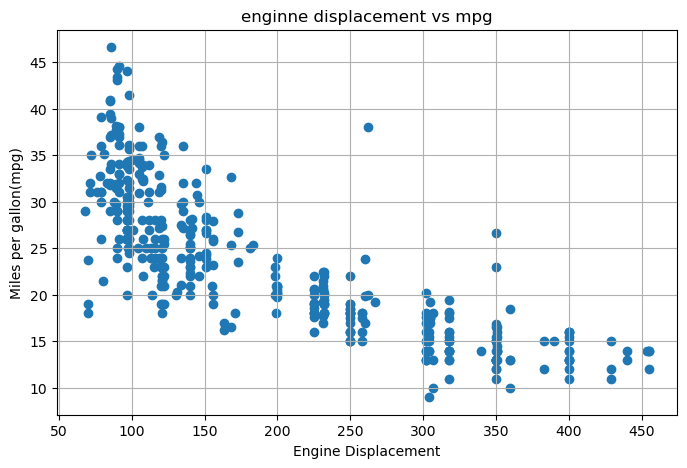

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(X,y)

plt.xlabel("Engine Displacement")
plt.ylabel("Miles per gallon(mpg)")
plt.title("enginne displacement vs mpg")
plt.grid(True)
plt.show()

In [22]:
#split te dataset
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

    
print(f"Training Samples:{len(X_train)}")
print(f"Testing Samples:{len(X_test)}")




    

Training Samples:318
Testing Samples:80


In [24]:
#create linear regression model
linear_model=LinearRegression()

#train the model
linear_model.fit(X_train,y_train)

#predict on test data
y_pred_linear=linear_model.predict(X_test)


In [26]:
#calculate MSE

mse_linear=mean_squared_error(y_test,y_pred_linear)

#calculate r2_score
r2_linear=r2_score(y_test,y_pred_linear)

print("Linear Regression Results")
print("..........................")
print(f"MSE {mse_linear}")
print(f"R2_score {r2_linear}")


Linear Regression Results
..........................
MSE 18.102543998358946
R2_score 0.6633114869465595


In [32]:
#store results

results=[]

#store polynomila models for plotting
polynomial_models={}
#add linear regression results
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R2_score':r2_linear,
})

#try plynomial degree in range 2-5
for degree in range(2,6):
    #crete polynimial features
    poly=PolynomialFeatures(degree=degree)
    
    #trnsform training and testing data
    
    X_train_poly=poly.fit_transform(X_train)
    X_test_poly=poly.transform(X_test)

    #create linear regression model

    poly_model=LinearRegression()

    #train polynomial  regression model

    poly_model.fit(X_train_poly,y_train)
    #make predictions

    y_pred_poly=poly_model.predict(X_test_poly)
    
    #calc evaluation metrics
    mse=mean_squared_error(y_test,y_pred_poly)
    r2=r2_score(y_test,y_pred_poly)



    #store results

    results.append({
        'Model':'PolynomialRegression',
        'Degree': degree,
        'MSE': mse,
        'R2_score':r2
    })


    #store model and polynimial transformer

    polynomial_models[degree]={
        'poly':poly,
        'model':poly_model,
    }

#convets results into dataframe
results_df=pd.DataFrame(results)

#display results

results_df
        
    
    



,Model,Degree,MSE,R2_score
0,Linear Regression,1,18.102544,0.663311
1,PolynomialRegression,2,15.107354,0.719019
2,PolynomialRegression,3,14.943632,0.722064
3,PolynomialRegression,4,14.961487,0.721732
4,PolynomialRegression,5,15.230896,0.716721


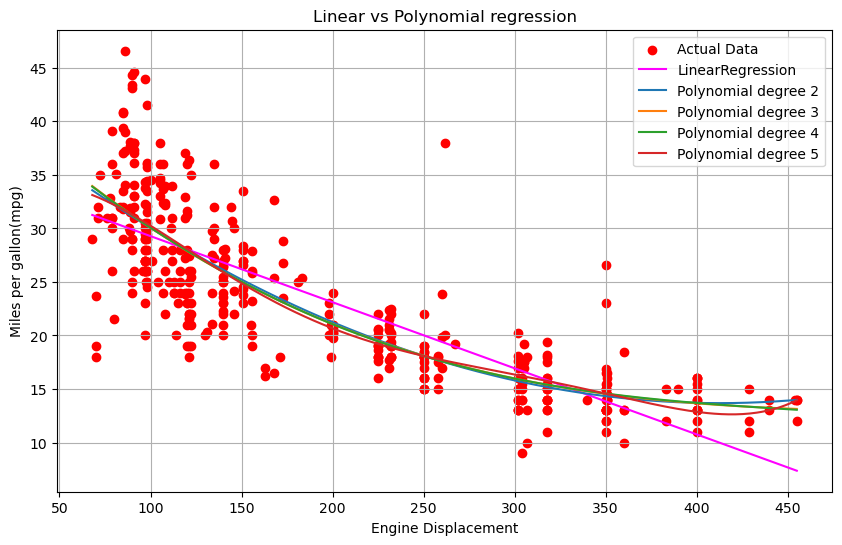

In [41]:
#crate smooth X values for plotting

X_plot=pd.DataFrame({
    'displacement':np.linspace(
        X['displacement'].min(),
        X['displacement'].max(),
        300)
})

#create figure
plt.figure(figsize=(10,6))



#plot actual data

plt.scatter(
    X['displacement'],
    y,
    label='Actual Data',
    color='red'
)
#plot lijnea regression

y_plot_linear=linear_model.predict(X_plot)

plt.plot(
    X_plot['displacement'],
    y_plot_linear,
    label='LinearRegression',
    color='magenta'
)
#plot polynomial regression

for degree in range(2,6):

   # retrieve stored trasformer and model

    poly=polynomial_models[degree]['poly']
    poly_model=polynomial_models[degree]['model']


    #transform smooth x values
    X_plot_poly=poly.transform(X_plot)

    #predict

    y_plot_poly=poly_model.predict(X_plot_poly)

    #plot curve

    plt.plot(
        X_plot['displacement'],
        y_plot_poly,
        label=f"Polynomial degree {degree}"
    )

#plot  formatting

plt.xlabel("Engine Displacement")
plt.ylabel("Miles per gallon(mpg)")
plt.title("Linear vs Polynomial regression :")

plt.legend()
plt.grid(True)
plt.show()



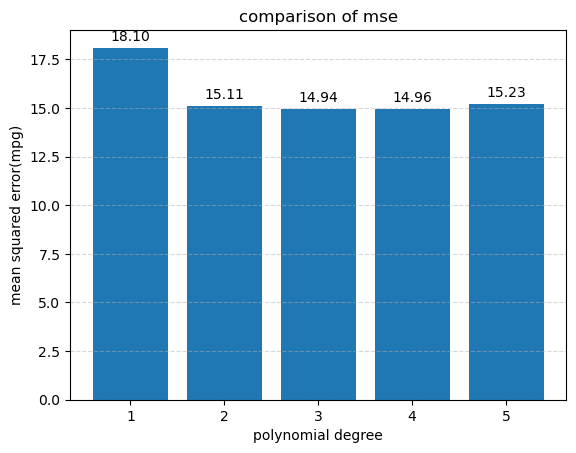

In [42]:
bars=plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

#add labels above bars

plt.bar_label(bars,fmt='%0.2f',padding=3)
plt.xlabel("polynomial degree")
plt.ylabel("mean squared error(mpg)")
plt.title("comparison of mse")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()



    

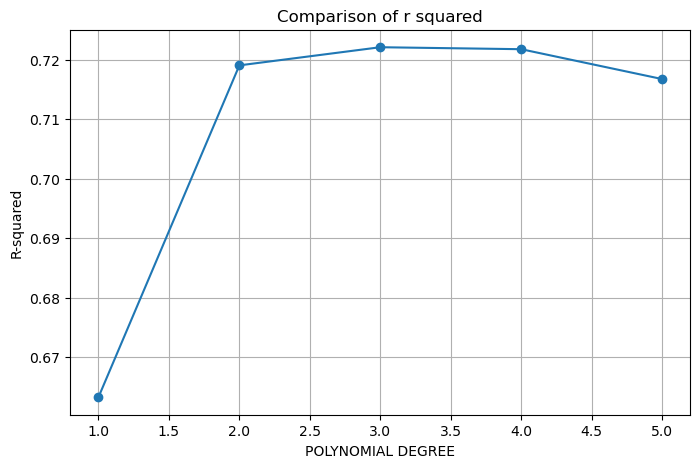

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df['Degree'],
    results_df['R2_score'],
    marker='o'
)


plt.xlabel("POLYNOMIAL DEGREE")
plt.ylabel("R-squared")
plt.title("Comparison of r squared")

plt.grid(True)
plt.show()

    